.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

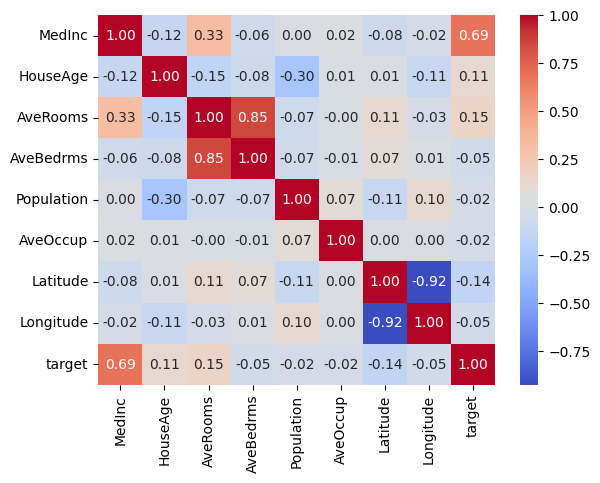

[('MedInc', np.float64(0.5224521855007008)), ('AveOccup', np.float64(0.1379665764733086)), ('Latitude', np.float64(0.0906344379866726)), ('Longitude', np.float64(0.08960859227684445)), ('HouseAge', np.float64(0.054168343148216974)), ('AveRooms', np.float64(0.04493439737294255)), ('Population', np.float64(0.03070501149983353)), ('AveBedrms', np.float64(0.029530455741480516))]
R Squared=0.81
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
[-0.82969334  0.00282077 -0.01219831 -0.00778918 -0.00170226 -0.24416989
 -0.32283476 -0.14426503]
Base Value=2.070
Predicted Price= 0.510
Actual=0.48


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


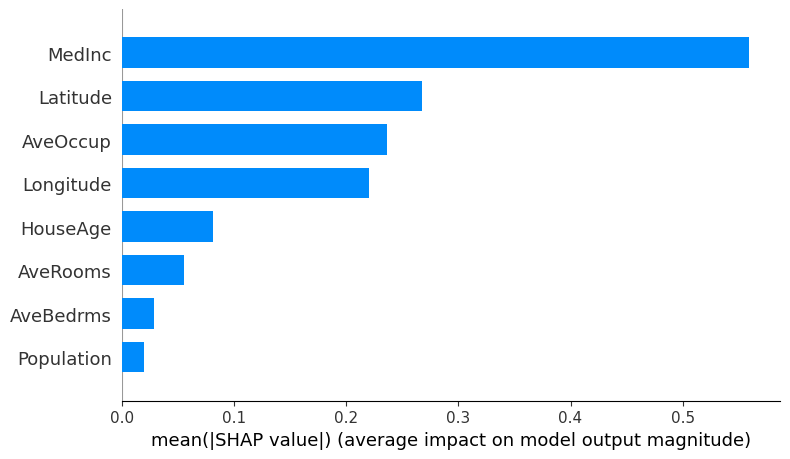

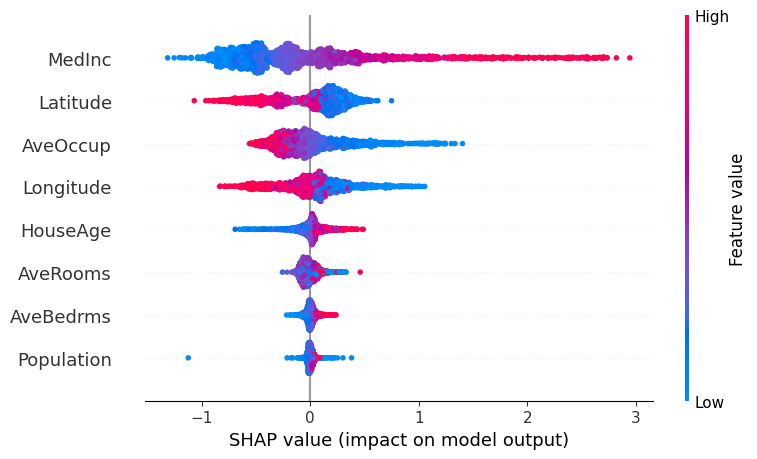

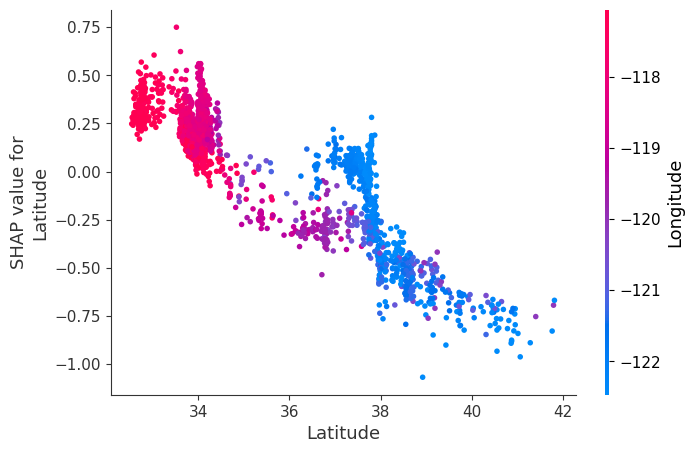

In [ ]:
#import the necessary packages
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_california_housing
from sklearn.ensemble import  RandomForestRegressor as RFR
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.metrics import accuracy_score


#get the data set
data = fetch_california_housing()


print(data.DESCR)
#print(data.feature_names)
#print(data.target_names)


#Check the dimensions of the data
x=data.data
print(x.shape)

y=data.target
#Put the data in a dataframe for easier visualization
import pandas as pd
columns=data.feature_names.copy()
df = pd.DataFrame(x, columns=columns)
df['target'] = y


df.head(10)


#get a summary of the data
df.describe()


#Print the correlation matrix
corrM=df.corr()
sns.heatmap(corrM, annot=True, cmap='coolwarm', fmt='.2f')
plt.show()


# split the data into training and test set
x=df[columns]
y=df['target']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.1, random_state=42)


# fit the model
model=RFR(n_estimators=100, random_state=42)
model = model.fit(x_train, y_train)


#print(model.summary())
importances=[]
for col, val in zip(columns,model.feature_importances_):
  importances.append((col, val))
importances.sort(key=lambda x: x[1], reverse=True)
print(importances)


#perform some predictions
predictions=model.predict(x_test)


print("R Squared={:.2f}".format(model.score(x_test, y_test)))


# Initialize SHAP explainer
explainer = shap.TreeExplainer(model)


# Calculate SHAP values using the test data
shap_values = explainer(x_test)
#print the Sharpley value for the first instance in the test data
print(columns)
print(shap_values.values[0])


#print the average/base value
print("Base Value={:.3f}".format(shap_values.base_values[0]))


#predict the price of the first instance in the test date


print("Predicted Price= {:.3f}".format(model.predict([x_test.iloc[0]])[0]))
print("Actual={:.2f}".format(y_test.iloc[0]))


#Plot the feature importances
shap.summary_plot(shap_values, x_test, plot_type='bar')


#Create the summary plot
shap.summary_plot(shap_values, x_test)


# Generate the dependence plot of Latutude on longitude
shap.dependence_plot("Latitude", shap_values.values, x_test, interaction_index="Longitude")


#Generate the force plot for the first instance in the test data
shap.initjs()
shap.force_plot(explainer.expected_value,shap_values.values[0,:], x_test.iloc[0,:])